In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('/content/cleaned_ecommerce.csv')  # upload your file in Colab
df.head()

,user_id,product_id,category,price_rs,discount_,final_pricers,payment_method,purchase_date,revenue,discount_value,month,year
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024,31.05,5.48,11,2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024,186.23,46.56,2,2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024,237.76,79.26,9,2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024,129.89,43.30,4,2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024,195.84,48.96,9,2024


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         3660 non-null   object 
 1   product_id      3660 non-null   object 
 2   category        3660 non-null   object 
 3   price_rs        3660 non-null   float64
 4   discount_       3660 non-null   int64  
 5   final_pricers   3660 non-null   float64
 6   payment_method  3660 non-null   object 
 7   purchase_date   3660 non-null   object 
 8   revenue         3660 non-null   float64
 9   discount_value  3660 non-null   float64
 10  month           3660 non-null   int64  
 11  year            3660 non-null   int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 343.3+ KB


,0
user_id,0
product_id,0
category,0
price_rs,0
discount_,0
final_pricers,0
payment_method,0
purchase_date,0
revenue,0
discount_value,0


In [4]:
total_revenue = df['revenue'].sum()
total_orders = df.shape[0]
avg_order_value = df['revenue'].mean()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Revenue: 757278.08
Total Orders: 3660
Average Order Value: 206.90657923497267


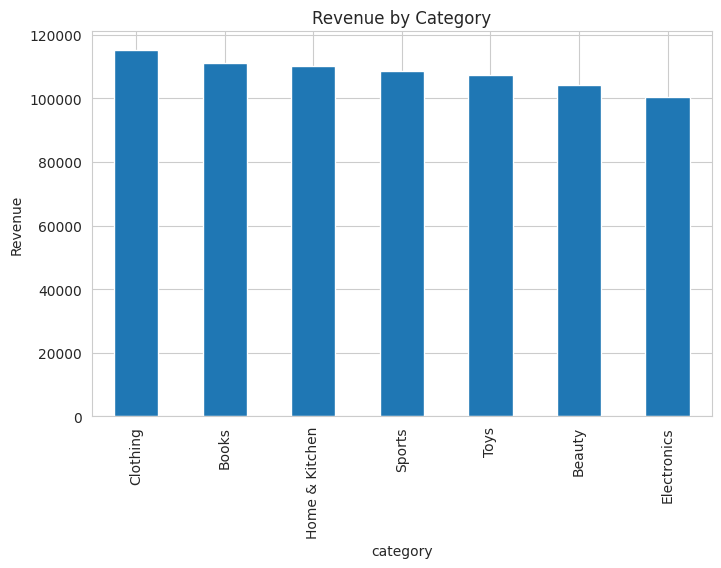

In [5]:
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

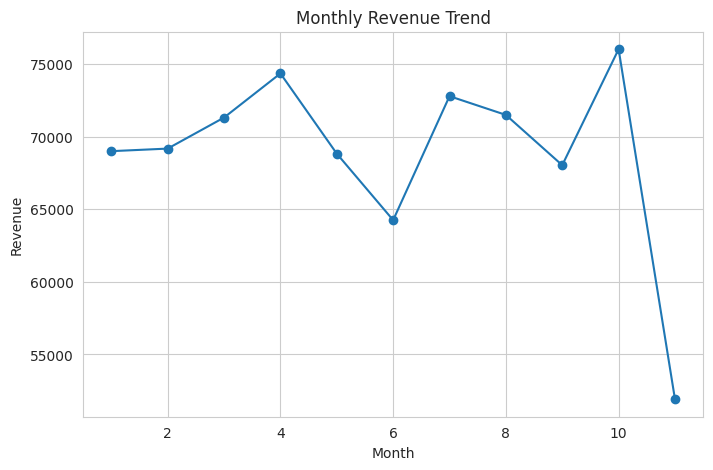

In [6]:
monthly_sales = df.groupby('month')['revenue'].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()

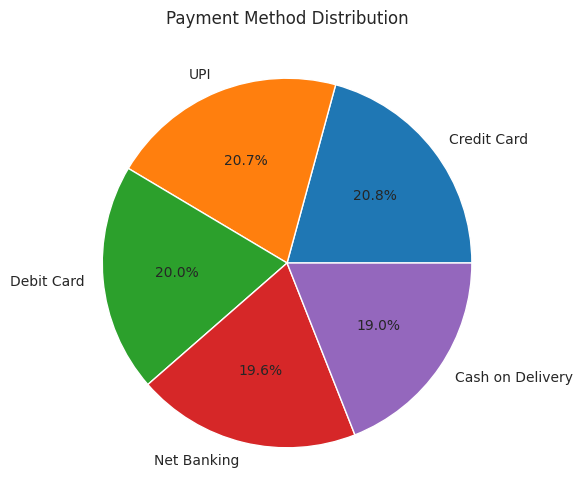

In [7]:
payment = df['payment_method'].value_counts()

plt.figure(figsize=(6,6))
payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel('')
plt.show()

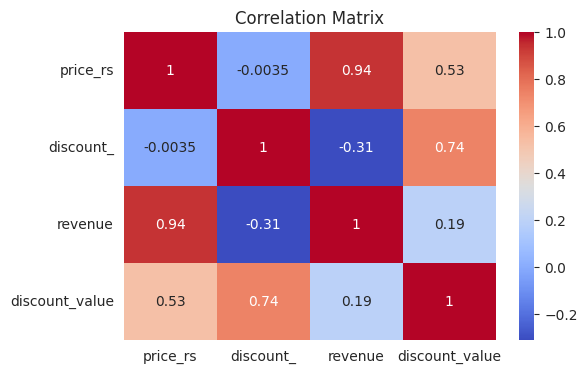

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['price_rs','discount_','revenue','discount_value']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

customer_data = df.groupby('user_id').agg({
    'revenue': 'sum',
    'product_id': 'count',
    'discount_value': 'sum'
}).rename(columns={'product_id': 'frequency'}).reset_index()

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_data[['revenue','frequency','discount_value']])

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
customer_data['cluster'] = kmeans.fit_predict(scaled_data)

customer_data.head()

,user_id,revenue,frequency,discount_value,cluster
0,001ae40d,345.93,1,86.48,0
1,0021e458,123.51,1,21.80,2
2,00333c7a,8.65,1,2.89,2
3,00390cf5,96.32,1,41.28,2
4,0041710c,388.45,1,20.45,0


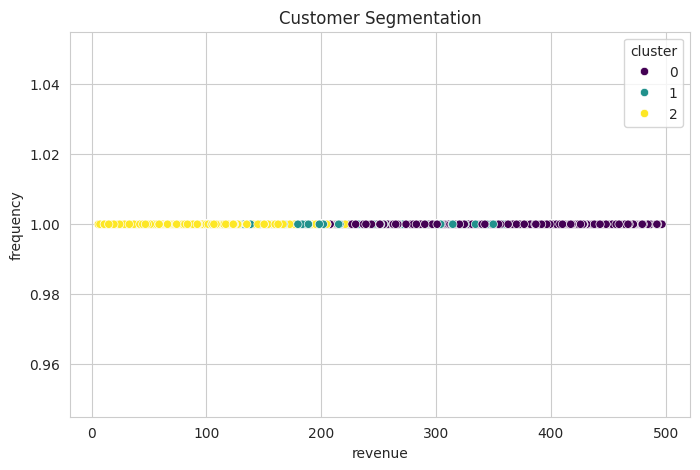

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=customer_data, x='revenue', y='frequency', hue='cluster', palette='viridis')
plt.title("Customer Segmentation")
plt.show()

<Axes: xlabel='revenue', ylabel='discount_value'>

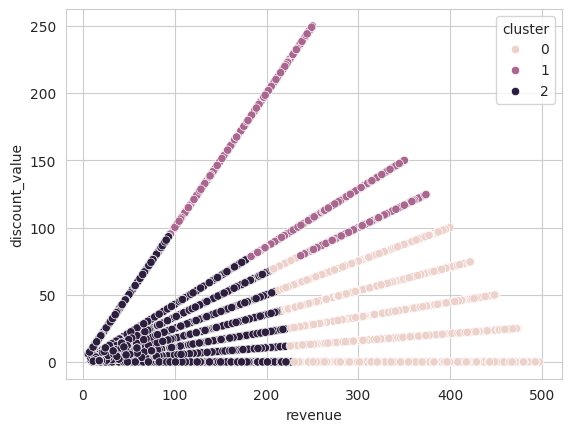

In [11]:
sns.scatterplot(
    data=customer_data,
    x='revenue',
    y='discount_value',
    hue='cluster'
)